# 02 — Speaker fingerprinting: does the corpus know who is talking?

**The problem this notebook exists for.** The corpus currently carries *no speaker identity at
all*. `speaker_id` is the literal string `spk0` on all 4,797 analytics rows — including the 15
episodes whose metadata declares two or more speakers. The only speaker information anywhere is
per-episode demographic slots (`spk0`/`spk1` → gender, age bracket, role), and those slot labels
are re-used across episodes with no linking. So the "12 individuals" figure quoted for this corpus
is derived from metadata that structurally *cannot* express identity.

That gap blocks three things:

1. **A leakage check nothing else can do.** D68 demoted episodes from gold for *show-level* host
   overlap. Guests and hosts cross shows. If a gold speaker also appears in train, the fine-tuning
   test set is contaminated and show-disjointness never catches it.
2. **The right clustering unit for the confidence intervals.** `01-EDA` bootstraps clustered by
   *episode*. If speakers recur across episodes, episodes are not independent either and the
   correct unit is the speaker — which will make the intervals **wider**, not narrower.
3. **Turning the diversity claim into a measurement.** Per-*speaker* duration, not per-episode, is
   what the sociolinguistic argument needs.

**What this notebook is.** A pilot, not the full run. It takes 13 short-to-medium episodes chosen
because their titles and declared metadata make a *falsifiable prediction* about who recurs, and
asks whether ECAPA speaker embeddings reproduce those predictions. If they do, the method is
trusted enough to run over all 40 episodes. If they do not, we learn that before spending the
compute.

**What it deliberately does not claim.** Speaker embedding clustering does not "know for sure" how
many people are in a corpus. The count is a function of a distance threshold, and cross-episode
same-speaker similarity degrades with a change of microphone, room, or codec. Everything below
reports a threshold sweep and a calibrated operating point, never a bare number.

**Why this model.** `speechbrain/spkrec-ecapa-voxceleb` is **ungated** on the Hub. The pyannote
diarization pipelines (`speaker-diarization-3.1`, `segmentation-3.0`) are `gated=auto` and need an
accepted-conditions token this project does not carry. ECAPA on 16 kHz mono is a good fit — the
corpus is already 16 kHz mono FLAC, so there is no resampling step to get wrong.

**Scope limit, stated up front.** Speech regions here come from the *labeled segments*, not from a
VAD pass over the full audio. That is the right choice for a pilot — those regions are
human-verified speech — but it means the pilot sees only the labeled fraction of each episode
(e.g. 7.2 of 21.7 minutes for `nepals_most_terrifying_flood`). A full corpus inventory would add a
VAD stage to reach the unlabeled remainder. Section 9 sizes that.

## 1. Setup

In [1]:
import os

# Unlike 01-EDA, this notebook does *not* fan out over processes: the work is one torch model
# applied to batches of audio, and torch's own intra-op pool is the thing that should own the
# cores. Pinning BLAS to one thread here would leave 15 of 16 idle.
os.environ.setdefault("OMP_NUM_THREADS", str(os.cpu_count()))
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import json
import time
import warnings
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
import torch
from sklearn.cluster import AgglomerativeClustering

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

torch.set_num_threads(os.cpu_count())
torch.set_grad_enabled(False)

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ANALYTICS = REPO / "exports" / "analytics" / "analytics.jsonl"
EPISODES = REPO / "data" / "objects" / "episodes"
MODELS = REPO / "data" / "models"
FIGURES = REPO / "notebooks" / "figures"
CACHE = REPO / "notebooks" / ".cache-diar"
FIGURES.mkdir(parents=True, exist_ok=True)
CACHE.mkdir(parents=True, exist_ok=True)

SR = 16_000            # every episode FLAC in this corpus is 16 kHz mono; asserted at load
WIN_SECONDS = 3.0      # ECAPA is trained on utterances of roughly this length
HOP_SECONDS = 1.5
MIN_WIN_SECONDS = 1.5  # shorter than this, an embedding is dominated by phonetic content

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 46)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

_style = "seaborn-v0_8-whitegrid"
plt.style.use(_style if _style in plt.style.available else "default")
plt.rcParams.update({"font.size": 9, "figure.autolayout": True, "figure.dpi": 110})

print(f"torch {torch.__version__} | threads {torch.get_num_threads()} | cwd {REPO}")
print(f"analytics export: {ANALYTICS.relative_to(REPO)} ({ANALYTICS.stat().st_size / 1e6:.0f} MB)")

torch 2.9.1+cpu | threads 16 | cwd /home/sagyam/Projects/labeling-harness
analytics export: exports/analytics/analytics.jsonl (79 MB)


## 2. The pilot roster, and the prediction each group makes

The 13 episodes below were not picked for being short. Each group encodes a hypothesis that the
embeddings can *fail*, which is what makes the pilot informative:

| group | prediction | why we believe it | what a failure would mean |
|---|---|---|---|
| `gadget` | 4 episodes, **one** recurring host | all four are phone unboxing/review, all declare a single 20–39 female host | either the method cannot link across episodes, or these really are four different reviewers |
| `binayak` | 3 episodes, **one** recurring voice | two titles name `binayak_kuikel`; all three declare a single 20–39 male | the `wso_` prefix means "with special guest" and the recurring voice is the host, not the guest — still a link, just a different person |
| `commentary` | **open question** — do these join `binayak`? | same declared demographics and genre, no shared name in the title | nothing; this group is a probe, not a control |
| `cooking` | 2 episodes, **one** recurring host | both cooking, both declare a single 40–59 female | as `gadget` |
| `two_speaker` | 2 episodes, **two** voices *within* each | declared metadata says so | within-episode clustering is miscounting |

`pixel_11_pro_vs_galaxy_s26_ultra` is in the roster for a specific reason: it sits in the **gold**
pot while the other three `gadget` episodes sit in **train**. If it links to them, gold and train
share a speaker and the show-level disjointness enforced by D68 did not close the leak.

The two `two_speaker` episodes are deliberately of unequal difficulty — one is a cross-gender pair
(easy), one is two women 20 years apart (hard). A method that only works on the easy one is not
usable on this corpus.

Everything in the `declared` columns is **metadata asserted at ingest, not ground truth.** It was
entered per episode by the annotator and has never been verified against the audio. Where the
embeddings disagree with it, either could be wrong, and the notebook says so rather than assuming
the metadata wins.

In [2]:
PILOT = {
    # group        episode_id                                    hypothesis
    "gadget":      ["honor_x6e_x7e_unboxing_dont_make_a_mista",
                    "redmi_17_4g_5g_unboxing_watch_before_buy",
                    "nothing_phone_4b_vs_nothing_phone_4a_whi",
                    "pixel_11_pro_vs_galaxy_s26_ultra_i_wasnt"],   # <- gold pot
    "binayak":     ["nepals_most_terrifying_flood_wso_binayak",
                    "old_faces_return_wso_binayak_kuikel",
                    "rsps_masterplan_wso_binayak_kuikel"],
    "commentary":  ["nepal_has_money_so_why_cant_it_build",
                    "why_do_they_keep_talking_nonsense"],
    "cooking":     ["rasbari_everything_explained_perfect_ras",
                    "_"],
    "two_speaker": ["just_say_youre_a_student_tea_talk_with_r",
                    "i_really_think_you_were_my_mother_in_the"],
}
GROUP_OF = {ep: g for g, eps in PILOT.items() for ep in eps}
PILOT_EPS = list(GROUP_OF)

# Segments and per-episode metadata, read once from the analytics export.
segments = defaultdict(list)
ep_meta = {}
with ANALYTICS.open() as fh:
    for line in fh:
        row = json.loads(line)
        ep = row["episode_id"]
        if ep not in GROUP_OF:
            continue
        segments[ep].append((row["start_time"], row["end_time"], row["segment_id"]))
        ep_meta.setdefault(ep, {"pot": row["pot"], **(row.get("episode_metadata") or {})})

rows = []
for ep in PILOT_EPS:
    spk = ep_meta[ep].get("speakers") or {}
    segs = sorted(segments[ep])
    with sf.SoundFile(EPISODES / ep / "audio.flac") as f:
        assert f.samplerate == SR and f.channels == 1, f"{ep}: expected 16 kHz mono"
        audio_min = len(f) / f.samplerate / 60
    rows.append({
        "group": GROUP_OF[ep],
        "episode": ep,
        "pot": ep_meta[ep]["pot"],
        "genre": ep_meta[ep].get("genre"),
        "audio_min": audio_min,
        "labeled_min": sum(e - s for s, e, _ in segs) / 60,
        "segs": len(segs),
        "declared_n": len(spk),
        "declared_who": ", ".join(f"{v['gender'][:1].upper()}/{v['age_bracket']}" for v in spk.values()),
    })

roster = pd.DataFrame(rows).sort_values(["group", "episode"]).reset_index(drop=True)
display(roster)
print(f"\n{len(roster)} episodes | {roster.audio_min.sum() / 60:.2f} h audio | "
      f"{roster.labeled_min.sum() / 60:.2f} h labeled speech | {roster.segs.sum():,} segments")
print(f"coverage: labeled speech is {roster.labeled_min.sum() / roster.audio_min.sum():.0%} of pilot audio")

,group,episode,pot,genre,audio_min,labeled_min,segs,declared_n,declared_who
0,binayak,nepals_most_terrifying_flood_wso_binayak,train,commentary,21.689,7.214,23,1,M/20_39
1,binayak,old_faces_return_wso_binayak_kuikel,train,podcast,20.357,16.565,51,1,M/20_39
2,binayak,rsps_masterplan_wso_binayak_kuikel,train,commentary,43.066,22.238,67,1,M/20_39
3,commentary,nepal_has_money_so_why_cant_it_build,train,commentary,23.307,10.556,32,1,M/20_39
4,commentary,why_do_they_keep_talking_nonsense,train,commentary,23.957,11.586,38,1,M/20_39
5,cooking,_,train,cooking,7.029,4.551,31,1,F/40_59
6,cooking,rasbari_everything_explained_perfect_ras,train,cooking,9.954,5.476,47,1,F/40_59
7,gadget,honor_x6e_x7e_unboxing_dont_make_a_mista,train,podcast,9.799,8.504,28,1,F/20_39
8,gadget,nothing_phone_4b_vs_nothing_phone_4a_whi,train,review,9.868,9.114,28,1,F/20_39
9,gadget,pixel_11_pro_vs_galaxy_s26_ultra_i_wasnt,gold,review,11.081,11.024,34,1,F/20_39



13 episodes | 3.81 h audio | 2.26 h labeled speech | 565 segments
coverage: labeled speech is 59% of pilot audio


## 3. Speech regions → fixed-length windows

Each labeled segment is cut into 3-second windows on a 1.5-second hop. Three seconds is where
ECAPA is most reliable; below about 1.5 s an embedding starts describing *what* was said more than
*who* said it, so shorter tails are dropped rather than padded from nothing.

Windows shorter than 3 s but at least 1.5 s are zero-padded to the window length and passed with
an explicit relative length (`wav_lens`), which is how SpeechBrain is told to ignore the padding.
Getting this wrong is a silent failure — the padding would be pooled into the statistics and every
short window would drift toward a common "half-silence" embedding — so it is worth the bookkeeping.

Note the two different hour counts printed below. The 1.5 s hop means consecutive windows overlap
by half, so the *window* hours (what the encoder actually processes, and the right denominator for
a throughput figure) are about 1.85x the *speech* hours (how much distinct audio is covered, and
the right denominator for coverage).

In [3]:
WIN = int(WIN_SECONDS * SR)
HOP = int(HOP_SECONDS * SR)
MIN_WIN = int(MIN_WIN_SECONDS * SR)


def episode_windows(ep: str) -> tuple[np.ndarray, np.ndarray, list[str]]:
    """Return (padded waveforms [n, WIN], relative lengths [n], source segment ids)."""
    audio, sr = sf.read(EPISODES / ep / "audio.flac", dtype="float32")
    assert sr == SR, f"{ep}: {sr} Hz"
    chunks, lens, src = [], [], []
    for start, end, seg_id in sorted(segments[ep]):
        a, b = int(start * SR), min(int(end * SR), len(audio))
        for off in range(a, max(a + 1, b - MIN_WIN + 1), HOP):
            piece = audio[off:min(off + WIN, b)]
            if len(piece) < MIN_WIN:
                break
            buf = np.zeros(WIN, dtype=np.float32)
            buf[:len(piece)] = piece
            chunks.append(buf)
            lens.append(len(piece) / WIN)
            src.append(seg_id)
    return np.stack(chunks), np.asarray(lens, dtype=np.float32), src


t0 = time.time()
windows = {ep: episode_windows(ep) for ep in PILOT_EPS}
n_win = sum(len(w[0]) for w in windows.values())
WINDOW_HOURS = sum(float(w[1].sum()) * WIN_SECONDS for w in windows.values()) / 3600
SPEECH_HOURS = roster.labeled_min.sum() / 60
print(f"cut {n_win:,} windows in {time.time() - t0:.1f}s")
print(f"  {WINDOW_HOURS:.2f} h of window audio (what the encoder sees)")
print(f"  {SPEECH_HOURS:.2f} h of distinct labeled speech "
      f"(overlap factor {WINDOW_HOURS / SPEECH_HOURS:.2f}x)")
display(pd.DataFrame(
    [{"episode": ep, "group": GROUP_OF[ep], "windows": len(windows[ep][0]),
      "mean_win_s": float(windows[ep][1].mean()) * WIN_SECONDS} for ep in PILOT_EPS]
).sort_values("windows", ascending=False).reset_index(drop=True))

cut 5,188 windows in 2.6s
  4.19 h of window audio (what the encoder sees)
  2.26 h of distinct labeled speech (overlap factor 1.85x)


,episode,group,windows,mean_win_s
0,rsps_masterplan_wso_binayak_kuikel,binayak,868,2.921
1,old_faces_return_wso_binayak_kuikel,binayak,646,2.920
2,i_really_think_you_were_my_mother_in_the,two_speaker,449,2.882
3,why_do_they_keep_talking_nonsense,commentary,447,2.928
4,pixel_11_pro_vs_galaxy_s26_ultra_i_wasnt,gadget,427,2.930
5,nepal_has_money_so_why_cant_it_build,commentary,411,2.924
6,nothing_phone_4b_vs_nothing_phone_4a_whi,gadget,354,2.926
7,redmi_17_4g_5g_unboxing_watch_before_buy,gadget,331,2.927
8,honor_x6e_x7e_unboxing_dont_make_a_mista,gadget,326,2.936
9,just_say_youre_a_student_tea_talk_with_r,two_speaker,285,2.794


## 4. Embedding

192-dimensional ECAPA-TDNN embeddings, L2-normalised so that a dot product *is* cosine similarity.
The model is cached under `data/models/` alongside the existing `mms_fa.onnx`, so a re-run does not
re-download it, and the embeddings themselves are cached under `notebooks/.cache-diar/` keyed by
the windowing parameters — re-running after changing a threshold does not re-embed.

In [4]:
from speechbrain.inference.speaker import EncoderClassifier

t0 = time.time()
encoder = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-ecapa-voxceleb",
    savedir=str(MODELS / "spkrec-ecapa-voxceleb"),
    run_opts={"device": "cpu"},
)
print(f"encoder loaded in {time.time() - t0:.1f}s")

BATCH = 64
CACHE_KEY = f"ecapa_w{WIN_SECONDS}_h{HOP_SECONDS}_m{MIN_WIN_SECONDS}"


def embed(ep: str) -> np.ndarray:
    path = CACHE / f"{CACHE_KEY}__{ep}.npy"
    if path.exists():
        return np.load(path)
    wavs, lens, _ = windows[ep]
    out = []
    for i in range(0, len(wavs), BATCH):
        batch = torch.from_numpy(wavs[i:i + BATCH])
        rel = torch.from_numpy(lens[i:i + BATCH])
        out.append(encoder.encode_batch(batch, wav_lens=rel).squeeze(1).numpy())
    emb = np.concatenate(out).astype(np.float32)
    emb /= np.linalg.norm(emb, axis=1, keepdims=True)
    np.save(path, emb)
    return emb


t0 = time.time()
E = {ep: embed(ep) for ep in PILOT_EPS}
ENCODE_SECONDS = time.time() - t0
print(f"{sum(len(v) for v in E.values()):,} embeddings of dim {next(iter(E.values())).shape[1]} "
      f"in {ENCODE_SECONDS:.1f}s")
if ENCODE_SECONDS > 1.0:  # a cached re-run would report a meaningless ratio
    print(f"throughput: {WINDOW_HOURS * 3600 / ENCODE_SECONDS:.0f}x realtime on "
          f"{torch.get_num_threads()} CPU threads")
else:
    print("(served from cache — clear notebooks/.cache-diar for a fresh timing)")

encoder loaded in 0.2s
5,188 embeddings of dim 192 in 0.0s
(served from cache — clear notebooks/.cache-diar for a fresh timing)


## 5. Within episode: how many voices does the audio contain?

Agglomerative clustering with average linkage on cosine distance, swept across thresholds. There
is no "correct" threshold to look up — it is a property of this audio, this model and this window
length — so the sweep is the result and the declared speaker count is the yardstick.

**A voice needs 30 seconds of speech to be counted.** The first run of this notebook used a
percentage-of-episode floor instead, and it let a 12-window (18-second) cluster through as a
"voice" in `nepals_most_terrifying_flood`, which then dragged that group's linking score down. A
centroid over 12 windows is noise. An absolute floor is also the more honest thing to state in a
paper: *this method cannot see anyone who speaks for less than half a minute*, and no percentage
threshold expresses that.

Two things to watch for, both expected:

- A **solo** episode can legitimately hold more than one voice. Review and commentary channels cut
  in b-roll, phone calls and clips of other people, and the labeled segments do not exclude them.
- The **same-gender** two-speaker episode (`i_really_think_you_were_my_mother`) is the hard case.
  If no threshold splits it into two while keeping solo episodes at one, the method has no usable
  operating point on this corpus.

In [5]:
MIN_VOICE_SECONDS = 30.0   # to be counted as a voice at all
MIN_LINK_SECONDS = 60.0    # to be trusted as a centroid for cross-episode linking

# Each window contributes HOP seconds of distinct speech (the rest overlaps its neighbour).
MIN_VOICE_WINDOWS = int(MIN_VOICE_SECONDS / HOP_SECONDS)
MIN_LINK_WINDOWS = int(MIN_LINK_SECONDS / HOP_SECONDS)

THRESHOLDS = np.round(np.arange(0.30, 0.95, 0.05), 2)


def cluster(emb: np.ndarray, threshold: float) -> np.ndarray:
    return AgglomerativeClustering(
        n_clusters=None, distance_threshold=threshold, metric="cosine", linkage="average"
    ).fit_predict(emb)


def voices_at(ep: str, threshold: float, min_windows: int = MIN_VOICE_WINDOWS) -> list[int]:
    labels = cluster(E[ep], threshold)
    return [c for c, n in Counter(labels).items() if n >= min_windows]


sweep = []
for ep in PILOT_EPS:
    row = {"group": GROUP_OF[ep], "episode": ep,
           "declared": len(ep_meta[ep].get("speakers") or {})}
    for t in THRESHOLDS:
        row[f"{t:.2f}"] = len(voices_at(ep, t))
    sweep.append(row)

sweep_df = pd.DataFrame(sweep).sort_values(["group", "episode"]).reset_index(drop=True)
display(sweep_df)

agree = {t: int((sweep_df[f"{t:.2f}"] == sweep_df["declared"]).sum()) for t in THRESHOLDS}
best = max(agree.values())
plateau = [t for t in THRESHOLDS if agree[t] == best]
WITHIN_DIST = float(np.median(plateau))
print(f"\nvoices >= {MIN_VOICE_SECONDS:.0f}s; agreement with the declared count by threshold:")
print("  " + ", ".join(f"{t:.2f}:{n}/{len(sweep_df)}" for t, n in agree.items()))
print(f"\nbest {best}/{len(sweep_df)} over thresholds "
      f"{plateau[0]:.2f}-{plateau[-1]:.2f}; using the middle of that plateau, "
      f"WITHIN_DIST = {WITHIN_DIST:.2f}")
mismatch = sweep_df[sweep_df[f"{WITHIN_DIST:.2f}"] != sweep_df["declared"]]
if len(mismatch):
    print("\nepisodes where the embeddings disagree with the declared count "
          "(either side may be wrong — resolving these needs listening):")
    display(mismatch[["group", "episode", "declared", f"{WITHIN_DIST:.2f}"]])

,group,episode,declared,0.30,0.35,0.40,0.45,0.50,0.55,0.60,0.65,0.70,0.75,0.80,0.85,0.90
0,binayak,nepals_most_terrifying_flood_wso_binayak,1,2,2,1,1,1,1,1,1,1,1,1,1,1
1,binayak,old_faces_return_wso_binayak_kuikel,1,5,4,1,1,1,1,1,1,1,1,1,1,1
2,binayak,rsps_masterplan_wso_binayak_kuikel,1,4,2,2,1,1,1,1,1,1,1,1,1,1
3,commentary,nepal_has_money_so_why_cant_it_build,1,4,5,2,1,1,1,1,1,1,1,1,1,1
4,commentary,why_do_they_keep_talking_nonsense,1,5,5,4,2,1,1,1,1,1,1,1,1,1
5,cooking,_,1,1,1,1,1,1,1,1,1,1,1,1,1,1
6,cooking,rasbari_everything_explained_perfect_ras,1,1,1,1,1,1,1,1,1,1,1,1,1,1
7,gadget,honor_x6e_x7e_unboxing_dont_make_a_mista,1,0,1,2,2,1,1,1,1,1,1,1,1,1
8,gadget,nothing_phone_4b_vs_nothing_phone_4a_whi,1,1,4,3,1,1,1,1,1,1,1,1,1,1
9,gadget,pixel_11_pro_vs_galaxy_s26_ultra_i_wasnt,1,0,1,2,1,2,1,1,1,1,1,1,1,1



voices >= 30s; agreement with the declared count by threshold:
  0.30:3/13, 0.35:5/13, 0.40:4/13, 0.45:11/13, 0.50:11/13, 0.55:13/13, 0.60:13/13, 0.65:13/13, 0.70:13/13, 0.75:13/13, 0.80:12/13, 0.85:11/13, 0.90:11/13

best 13/13 over thresholds 0.55-0.75; using the middle of that plateau, WITHIN_DIST = 0.65


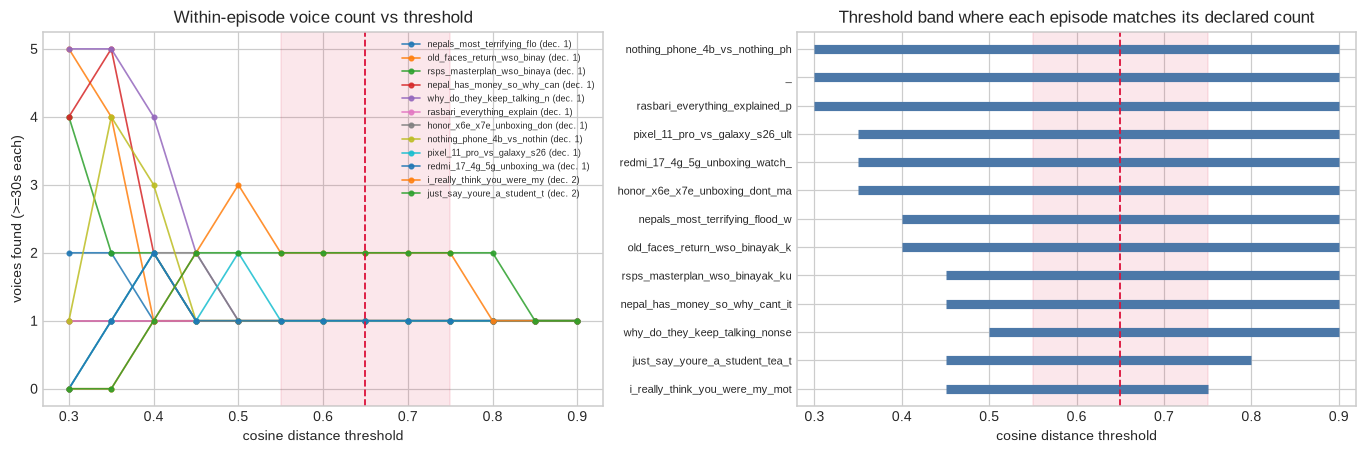

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

ax = axes[0]
for _, r in sweep_df.iterrows():
    ax.plot(THRESHOLDS, [r[f"{t:.2f}"] for t in THRESHOLDS], marker=".", lw=1.1, alpha=0.85,
            label=f"{r.episode[:26]} (dec. {r.declared})")
ax.axvspan(plateau[0], plateau[-1], color="crimson", alpha=0.10)
ax.axvline(WITHIN_DIST, color="crimson", ls="--", lw=1.2)
ax.set(xlabel="cosine distance threshold", ylabel=f"voices found (>={MIN_VOICE_SECONDS:.0f}s each)",
       title="Within-episode voice count vs threshold")
ax.legend(fontsize=6.0, loc="upper right")

# Right panel: for each episode, the band of thresholds over which the count matches the
# declared one. A wide band means the episode is robust; a narrow one means its count is a
# tuning artefact. An episode that never matches gets a marker at the axis and a red label,
# which is the case worth seeing at a glance.
ax = axes[1]
bands = []
for _, r in sweep_df.iterrows():
    ok = [t for t in THRESHOLDS if r[f"{t:.2f}"] == r["declared"]]
    bands.append({"episode": r.episode, "lo": min(ok) if ok else np.nan,
                  "hi": max(ok) if ok else np.nan, "width": len(ok) and max(ok) - min(ok)})
bands = pd.DataFrame(bands).sort_values("width", ascending=True).reset_index(drop=True)
for y, r in bands.iterrows():
    if np.isnan(r.lo):
        ax.plot(THRESHOLDS[0], y, marker="x", color="#E45756", ms=8)
        continue
    ax.plot([r.lo, r.hi], [y, y], lw=6, solid_capstyle="butt",
            color="#4C78A8" if r.width >= 0.15 else "#F0A202")
ax.axvspan(plateau[0], plateau[-1], color="crimson", alpha=0.10)
ax.axvline(WITHIN_DIST, color="crimson", ls="--", lw=1.2)
ax.set_yticks(range(len(bands)), bands.episode.str.slice(0, 30), fontsize=7.5)
for tick, lo in zip(ax.get_yticklabels(), bands.lo):
    if np.isnan(lo):
        tick.set_color("#E45756")
ax.set(xlabel="cosine distance threshold", xlim=(THRESHOLDS[0] - 0.02, THRESHOLDS[-1] + 0.02),
       title="Threshold band where each episode matches its declared count")

fig.savefig(FIGURES / "diar_01_within_episode_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Is the embedding space separable at all?

Before any linking decision, a sanity check on the space itself, built from window pairs whose
label follows from something stronger than metadata:

- **Positives** — two windows from the same *solo-declared* episode. Same person, same session.
- **Negatives** — two windows from episodes whose declared speakers are all of different genders
  (any `gadget` window against any `binayak` window). Cross-gender confusion is rare enough in
  ECAPA that these are near-certainly different people.

**This EER is a diagnostic, not the linking threshold.** It is measured on single 3-second
windows, whereas section 7 decides on *centroids* averaged over hundreds of windows, which are far
better separated. The first run of this notebook used the window-level EER point (cosine 0.26) as
the linking threshold and it was badly too permissive — several between-group voice pairs sat at
0.32, above it. Section 7 derives its threshold at the granularity it actually decides at.

**The positives are also the easy kind, so this number is optimistic.** Same-session pairs share
microphone, room and codec. The hard case — same speaker, *different* episode — is what sections 7
and 8 test, and it is deliberately kept out of this calibration, because using it here would
assume the answer.

In [7]:
rng = np.random.default_rng(20260101)
solo = [ep for ep in PILOT_EPS if len(ep_meta[ep].get("speakers") or {}) == 1]


def genders(ep: str) -> set[str]:
    return {v["gender"] for v in (ep_meta[ep].get("speakers") or {}).values()}


def sample_sims(pairs, n=40_000):
    out = []
    for a_ep, b_ep in pairs:
        ea, eb = E[a_ep], E[b_ep]
        k = n // max(1, len(pairs))
        i, j = rng.integers(0, len(ea), size=k), rng.integers(0, len(eb), size=k)
        if a_ep == b_ep:
            ok = i != j
            i, j = i[ok], j[ok]
        out.append(np.einsum("ij,ij->i", ea[i], eb[j]))
    return np.concatenate(out)


pos = sample_sims([(ep, ep) for ep in solo])
neg_pairs = [(a, b) for a in PILOT_EPS for b in PILOT_EPS
             if a < b and not (genders(a) & genders(b))]
neg = sample_sims(neg_pairs)

grid = np.linspace(-0.2, 1.0, 601)
far = np.array([(neg >= t).mean() for t in grid])
frr = np.array([(pos < t).mean() for t in grid])
k = int(np.argmin(np.abs(far - frr)))
eer_sim, eer = float(grid[k]), float((far[k] + frr[k]) / 2)

print(f"positives: {len(pos):,} same-solo-episode window pairs from {len(solo)} episodes")
print(f"negatives: {len(neg):,} cross-gender window pairs from {len(neg_pairs)} episode pairs")
print(f"  same-speaker  cosine  mean {pos.mean():.3f}  p5  {np.percentile(pos, 5):.3f}")
print(f"  diff-speaker  cosine  mean {neg.mean():.3f}  p95 {np.percentile(neg, 95):.3f}")
print(f"\nwindow-level EER {eer:.2%} at cosine {eer_sim:.3f} - the space separates speakers.")
print("Not used as the linking threshold; see section 7.")

positives: 39,891 same-solo-episode window pairs from 11 episodes
negatives: 39,970 cross-gender window pairs from 35 episode pairs
  same-speaker  cosine  mean 0.608  p5  0.428
  diff-speaker  cosine  mean 0.083  p95 0.218

window-level EER 1.72% at cosine 0.264 - the space separates speakers.
Not used as the linking threshold; see section 7.


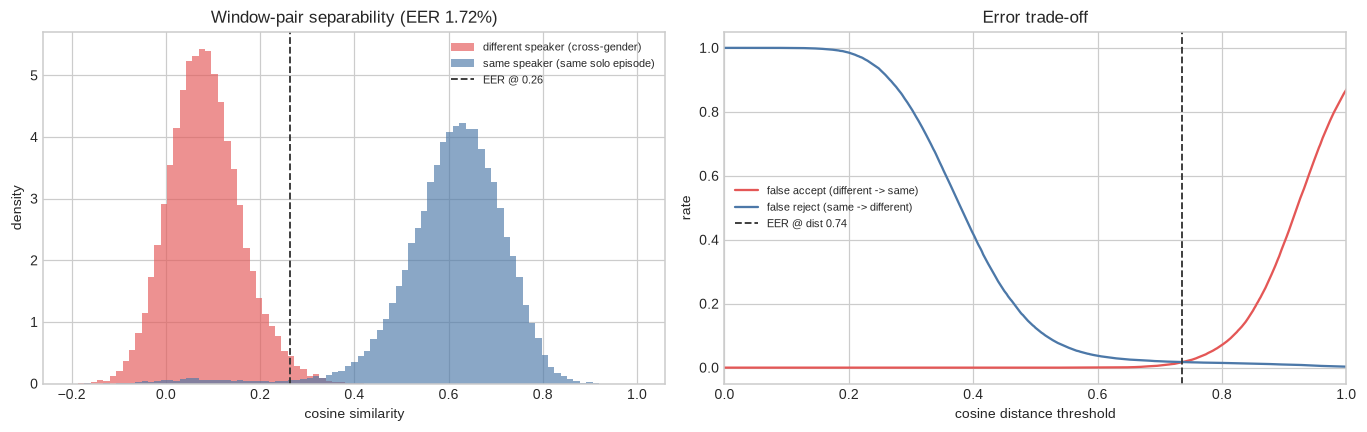

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0))

ax = axes[0]
bins = np.linspace(-0.2, 1.0, 90)
ax.hist(neg, bins=bins, alpha=0.65, density=True, color="#E45756",
        label="different speaker (cross-gender)")
ax.hist(pos, bins=bins, alpha=0.65, density=True, color="#4C78A8",
        label="same speaker (same solo episode)")
ax.axvline(eer_sim, color="0.2", ls="--", lw=1.2, label=f"EER @ {eer_sim:.2f}")
ax.set(xlabel="cosine similarity", ylabel="density",
       title=f"Window-pair separability (EER {eer:.2%})")
ax.legend(fontsize=7.5)

ax = axes[1]
ax.plot(1 - grid, far, color="#E45756", label="false accept (different -> same)")
ax.plot(1 - grid, frr, color="#4C78A8", label="false reject (same -> different)")
ax.axvline(1 - eer_sim, color="0.2", ls="--", lw=1.2, label=f"EER @ dist {1 - eer_sim:.2f}")
ax.set(xlabel="cosine distance threshold", ylabel="rate", title="Error trade-off", xlim=(0, 1))
ax.legend(fontsize=7.5)

fig.savefig(FIGURES / "diar_02_calibration.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Across episodes: linking voices

A single mean embedding per episode is wrong for anything with a guest — it averages two people
into a centroid that matches neither. So this is two-stage, the standard shape:

1. **Within each episode**, cluster windows into voices at `WITHIN_DIST` and keep those holding at
   least 30 s of speech. Each gets a renormalised centroid.
2. **Across episodes**, compare centroids — but only those with at least 60 s behind them, since a
   centroid is only as stable as the audio averaged into it.

**The threshold is read off the data, not chosen.** All cross-episode voice-pair similarities are
sorted and the largest gap in that list is found. If the gap is wide, every threshold inside it
produces the *same* partition, and the linking result is a property of the corpus rather than of a
tuning decision. If the gap is narrow, the opposite is true and the result should not be
trusted — so the width is reported either way.

In [9]:
rows = []
for ep in PILOT_EPS:
    labels = cluster(E[ep], WITHIN_DIST)
    for rank, (c, n) in enumerate(sorted(Counter(labels).items(), key=lambda kv: -kv[1])):
        if n < MIN_VOICE_WINDOWS:
            continue
        centroid = E[ep][labels == c].mean(axis=0)
        rows.append({
            "episode": ep, "group": GROUP_OF[ep], "pot": ep_meta[ep]["pot"],
            "voice": f"{ep[:24]}#{rank}", "windows": n,
            "speech_min": n * HOP_SECONDS / 60,
            "centroid": centroid / np.linalg.norm(centroid),
        })

V = (pd.DataFrame(rows)
     .sort_values(["group", "episode", "windows"], ascending=[True, True, False])
     .reset_index(drop=True))
V["linkable"] = V.windows >= MIN_LINK_WINDOWS
C = np.stack(V.centroid.to_numpy())
S = C @ C.T

print(f"{len(V)} voices >={MIN_VOICE_SECONDS:.0f}s across {len(PILOT_EPS)} episodes "
      f"at within-episode threshold {WITHIN_DIST:.2f}")
print(f"{int(V.linkable.sum())} of them carry >={MIN_LINK_SECONDS:.0f}s and are used for linking")
display(V.drop(columns="centroid"))

15 voices >=30s across 13 episodes at within-episode threshold 0.65
15 of them carry >=60s and are used for linking


,episode,group,pot,voice,windows,speech_min,linkable
0,nepals_most_terrifying_flood_wso_binayak,binayak,train,nepals_most_terrifying_f#0,268,6.700,True
1,old_faces_return_wso_binayak_kuikel,binayak,train,old_faces_return_wso_bin#0,639,15.975,True
2,rsps_masterplan_wso_binayak_kuikel,binayak,train,rsps_masterplan_wso_bina#0,868,21.700,True
3,nepal_has_money_so_why_cant_it_build,commentary,train,nepal_has_money_so_why_c#0,411,10.275,True
4,why_do_they_keep_talking_nonsense,commentary,train,why_do_they_keep_talking#0,439,10.975,True
5,_,cooking,train,_#0,166,4.150,True
6,rasbari_everything_explained_perfect_ras,cooking,train,rasbari_everything_expla#0,195,4.875,True
7,honor_x6e_x7e_unboxing_dont_make_a_mista,gadget,train,honor_x6e_x7e_unboxing_d#0,326,8.150,True
8,nothing_phone_4b_vs_nothing_phone_4a_whi,gadget,train,nothing_phone_4b_vs_noth#0,354,8.850,True
9,pixel_11_pro_vs_galaxy_s26_ultra_i_wasnt,gadget,gold,pixel_11_pro_vs_galaxy_s#0,427,10.675,True


In [10]:
L = V.index[V.linkable].to_numpy()
pairs = [(i, j, float(S[i, j])) for a, i in enumerate(L) for j in L[a + 1:]
         if V.episode[i] != V.episode[j]]
sims = np.array(sorted(s for _, _, s in pairs))

gaps = np.diff(sims)
g = int(np.argmax(gaps))
GAP_LO, GAP_HI = float(sims[g]), float(sims[g + 1])
LINK = (GAP_LO + GAP_HI) / 2

print(f"{len(pairs)} cross-episode voice pairs")
print(f"  {int((sims <= GAP_LO).sum())} below the gap, max {GAP_LO:.3f}")
print(f"  {int((sims >= GAP_HI).sum())} above the gap, min {GAP_HI:.3f}")
print(f"\nlargest gap: {GAP_LO:.3f} -> {GAP_HI:.3f}  (width {GAP_HI - GAP_LO:.3f})")
print(f"LINK threshold = {LINK:.3f}; any value in that gap gives an identical partition.")
if GAP_HI - GAP_LO < 0.15:
    print("\n** The gap is narrow. The partition below depends on the threshold and is NOT safe **")
else:
    print(f"\nThe decision is insensitive to the threshold across {GAP_HI - GAP_LO:.2f} of cosine.")

103 cross-episode voice pairs
  92 below the gap, max 0.362
  11 above the gap, min 0.806

largest gap: 0.362 -> 0.806  (width 0.444)
LINK threshold = 0.584; any value in that gap gives an identical partition.

The decision is insensitive to the threshold across 0.44 of cosine.


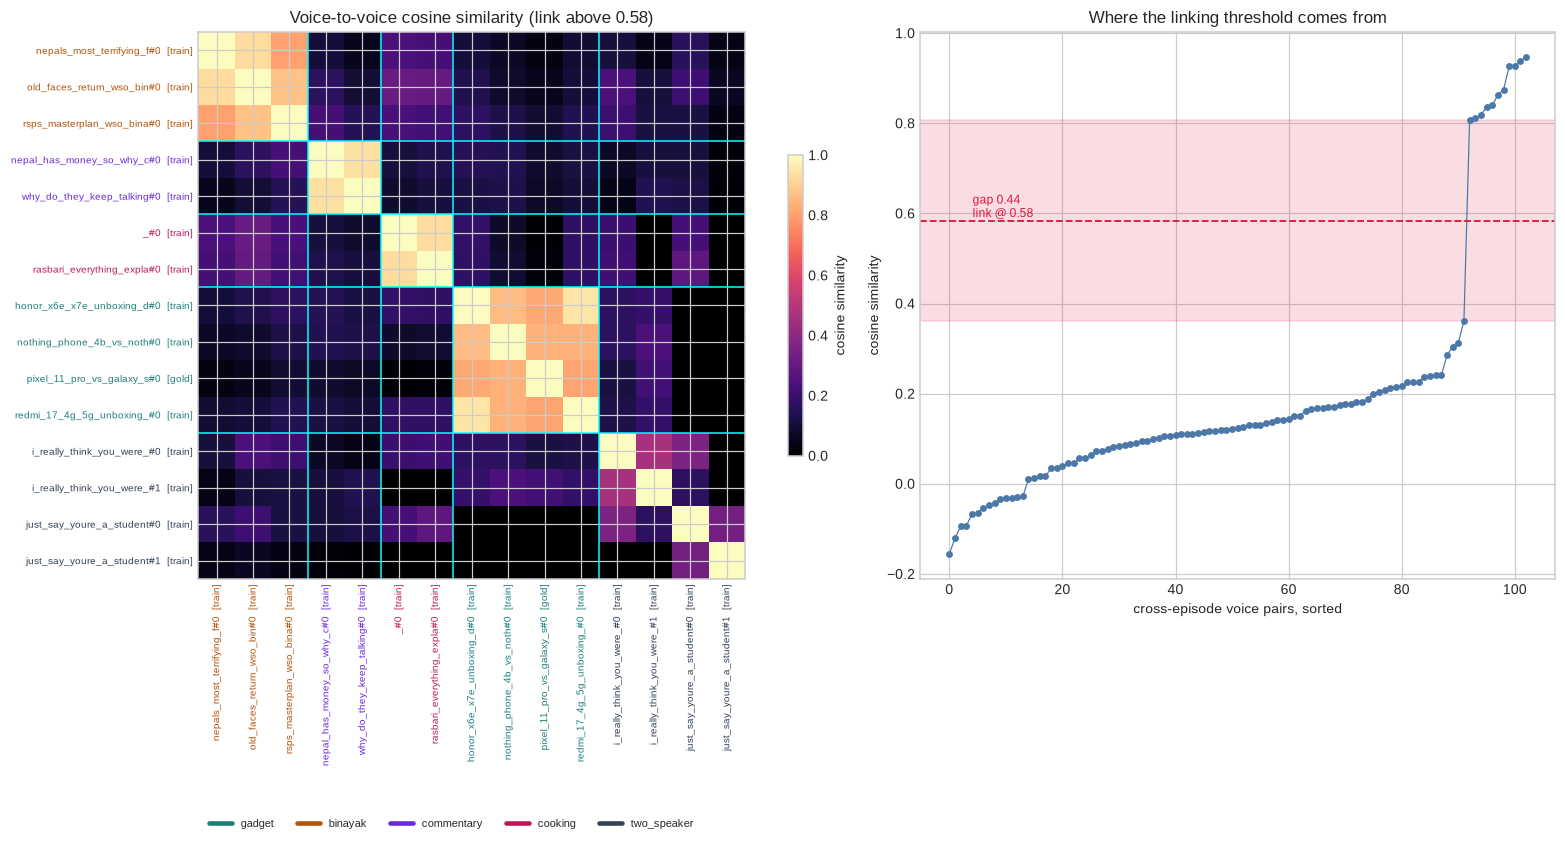

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 8.2),
                         gridspec_kw={"width_ratios": [1.35, 1]})

ax = axes[0]
im = ax.imshow(S, cmap="magma", vmin=0.0, vmax=1.0)
labels = [f"{r.voice}  [{r.pot}]{'' if r.linkable else '  (short)'}" for r in V.itertuples()]
ax.set_xticks(range(len(V)), labels, rotation=90, fontsize=6.5)
ax.set_yticks(range(len(V)), labels, fontsize=6.5)
for b in np.flatnonzero(V.group.ne(V.group.shift())).tolist()[1:]:
    ax.axhline(b - 0.5, color="cyan", lw=1.0)
    ax.axvline(b - 0.5, color="cyan", lw=1.0)
# Group membership is carried by the tick-label colour rather than by text beside the axis,
# which collided with the (long) voice names.
palette = dict(zip(PILOT, ["#1B7F79", "#B45309", "#6D28D9", "#BE185D", "#334155"]))
for tick, g_ in zip(ax.get_yticklabels(), V.group):
    tick.set_color(palette[g_])
for tick, g_ in zip(ax.get_xticklabels(), V.group):
    tick.set_color(palette[g_])
ax.legend(handles=[plt.Line2D([], [], color=c, lw=3, label=g_) for g_, c in palette.items()],
          loc="upper left", bbox_to_anchor=(0, -0.42), ncol=5, fontsize=7.5, frameon=False)
ax.set_title(f"Voice-to-voice cosine similarity (link above {LINK:.2f})")
fig.colorbar(im, ax=ax, shrink=0.55, label="cosine similarity")

ax = axes[1]
ax.plot(range(len(sims)), sims, marker="o", ms=3.5, lw=0.8, color="#4C78A8")
ax.axhspan(GAP_LO, GAP_HI, color="crimson", alpha=0.14)
ax.axhline(LINK, color="crimson", ls="--", lw=1.2)
ax.annotate(f"gap {GAP_HI - GAP_LO:.2f}\nlink @ {LINK:.2f}", xy=(len(sims) * 0.04, LINK),
            fontsize=8, color="crimson", va="bottom")
ax.set(xlabel="cross-episode voice pairs, sorted", ylabel="cosine similarity",
       title="Where the linking threshold comes from")

fig.savefig(FIGURES / "diar_03_voice_similarity.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Do the predictions hold?

Each group from section 2 is scored on the mean cross-*episode* similarity among its linkable
voices, against the mean similarity of those voices to everything outside the group.

`two_speaker` is marked **n/a**: its two episodes are unrelated to each other, and its prediction
was about the *within*-episode count, which section 5 already tested. Scoring it for cross-episode
linking — as the first run of this notebook did — asks it a question it was never posed.

In [12]:
LINKING_GROUPS = [g for g in PILOT if g != "two_speaker"]


def group_report(group: str) -> dict:
    idx = V.index[(V.group == group) & V.linkable].to_numpy()
    out_idx = V.index[(V.group != group) & V.linkable].to_numpy()
    within = [S[i, j] for a, i in enumerate(idx) for j in idx[a + 1:]
              if V.episode[i] != V.episode[j]]
    between = S[np.ix_(idx, out_idx)].ravel()
    return {"group": group, "voices": len(idx), "episodes": V.episode[idx].nunique(),
            "within_mean": float(np.mean(within)) if within else np.nan,
            "within_min": float(np.min(within)) if within else np.nan,
            "between_mean": float(between.mean()) if len(between) else np.nan,
            "between_max": float(between.max()) if len(between) else np.nan,
            "linked": bool(within and np.min(within) >= LINK)}


report = pd.DataFrame([group_report(g) for g in LINKING_GROUPS])
display(report)

print(f"link threshold {LINK:.3f} (gap {GAP_LO:.3f}-{GAP_HI:.3f})\n")
for _, r in report.iterrows():
    if np.isnan(r.within_mean):
        print(f"  {r.group:<12} n/a - fewer than two episodes contributed a linkable voice")
        continue
    verdict = ("CONFIRMED" if r.linked
               else "SPLIT" if r.within_mean >= LINK else "NOT SUPPORTED")
    print(f"  {r.group:<12} {verdict:<14} within {r.within_mean:.3f} (min {r.within_min:.3f})"
          f"   between {r.between_mean:.3f} (max {r.between_max:.3f})")
print(f"  {'two_speaker':<12} n/a            tested in section 5, not here")

ts = sweep_df[sweep_df.group == "two_speaker"]
print(f"\n  section 5 recheck at {WITHIN_DIST:.2f} - "
      + "; ".join(f"{r.episode[:34]}: {r[f'{WITHIN_DIST:.2f}']} found vs {r.declared} declared"
                  for _, r in ts.iterrows()))

,group,voices,episodes,within_mean,within_min,between_mean,between_max,linked
0,gadget,4,4,0.853,0.811,0.090,0.241,True
1,binayak,3,3,0.869,0.806,0.140,0.312,True
2,commentary,2,2,0.938,0.938,0.109,0.226,True
3,cooking,2,2,0.926,0.926,0.137,0.312,True


link threshold 0.584 (gap 0.362-0.806)

  gadget       CONFIRMED      within 0.853 (min 0.811)   between 0.090 (max 0.241)
  binayak      CONFIRMED      within 0.869 (min 0.806)   between 0.140 (max 0.312)
  commentary   CONFIRMED      within 0.938 (min 0.938)   between 0.109 (max 0.226)
  cooking      CONFIRMED      within 0.926 (min 0.926)   between 0.137 (max 0.312)
  two_speaker  n/a            tested in section 5, not here

  section 5 recheck at 0.65 - i_really_think_you_were_my_mother_: 2 found vs 2 declared; just_say_youre_a_student_tea_talk_: 2 found vs 2 declared


### 8a. The speaker inventory this implies

Linking every voice above the threshold and taking connected components gives the pilot's estimate
of *distinct people*, with the episodes and pots each one spans. This is the shape the full run
would write back to the corpus as a real `speaker_id`.

In [13]:
adj = (S >= LINK)
seen, speakers = set(), []
for i in L:
    if i in seen:
        continue
    comp, stack = set(), [i]
    while stack:                       # connected components over the link graph
        k = stack.pop()
        if k in comp:
            continue
        comp.add(k)
        stack.extend(j for j in L if j not in comp and adj[k, j])
    seen |= comp
    sub = V.loc[sorted(comp)]
    speakers.append({
        "speaker": f"S{len(speakers):02d}",
        "voices": len(comp),
        "episodes": sub.episode.nunique(),
        "pots": ",".join(sorted(sub.pot.unique())),
        "speech_min": float(sub.speech_min.sum()),
        "spans": " | ".join(sorted(e[:26] for e in sub.episode.unique())),
    })

inv = pd.DataFrame(speakers).sort_values("speech_min", ascending=False).reset_index(drop=True)
display(inv)

short = V[~V.linkable]
print(f"{len(inv)} distinct speakers across {len(PILOT_EPS)} episodes "
      f"(from {int(V.linkable.sum())} linkable voices)")
print(f"episodes per speaker: max {inv.episodes.max()}, "
      f"{int((inv.episodes > 1).sum())} speaker(s) recur across episodes")
if len(short):
    print(f"\n{len(short)} voice(s) between {MIN_VOICE_SECONDS:.0f}s and {MIN_LINK_SECONDS:.0f}s "
          f"were left unassigned (too little audio to link):")
    display(short[["episode", "voice", "speech_min"]])

,speaker,voices,episodes,pots,speech_min,spans
0,S00,3,3,train,44.375,nepals_most_terrifying_flo | old_faces_ret...
1,S03,4,4,"gold,train",35.725,honor_x6e_x7e_unboxing_don | nothing_phone...
2,S01,2,2,train,21.250,nepal_has_money_so_why_can | why_do_they_k...
3,S02,2,2,train,9.025,_ | rasbari_everything_explain
4,S04,1,1,train,5.325,i_really_think_you_were_my
5,S05,1,1,train,4.500,i_really_think_you_were_my
6,S06,1,1,train,3.075,just_say_youre_a_student_t
7,S07,1,1,train,2.575,just_say_youre_a_student_t


8 distinct speakers across 13 episodes (from 15 linkable voices)
episodes per speaker: max 4, 4 speaker(s) recur across episodes


### 8b. The leakage question

Does a voice in a **gold** episode link to a voice in a **train** episode? This is the check that
show-level disjointness cannot perform, and it has a direct consequence: a shared speaker means
the fine-tuning test set is not speaker-held-out, and a model fine-tuned on train has heard the
test voice.

In [14]:
gold_i = V.index[(V.pot == "gold") & V.linkable].to_numpy()
train_i = V.index[(V.pot == "train") & V.linkable].to_numpy()

leaks = [{"gold_episode": V.episode[i], "train_episode": V.episode[j],
          "similarity": float(S[i, j]),
          "gold_min": V.speech_min[i], "train_min": V.speech_min[j]}
         for i in gold_i for j in train_i if S[i, j] >= LINK]

if leaks:
    lk = pd.DataFrame(leaks).sort_values("similarity", ascending=False).reset_index(drop=True)
    display(lk)
    print(f"\n{len(lk)} gold-train voice link(s) at cosine >= {LINK:.3f}, covering "
          f"{lk.gold_episode.nunique()} gold and {lk.train_episode.nunique()} train episode(s).")
    print(f"Weakest link {lk.similarity.min():.3f}; strongest non-link anywhere in the "
          f"matrix is {GAP_LO:.3f}. The margin is {lk.similarity.min() - GAP_LO:.3f}.")
    print("\nWithin this pilot, gold and train share a speaker.")
else:
    best = S[np.ix_(gold_i, train_i)].max() if len(gold_i) and len(train_i) else float("nan")
    print(f"No gold-train voice link at cosine >= {LINK:.3f}. Closest pair: {best:.3f}.")
print(f"\nScope: {len(PILOT_EPS)} of 40 episodes and 1 of 5 gold episodes. A clean result here "
      "would not be evidence that the corpus is leak-free - only the full run can say that.")

,gold_episode,train_episode,similarity,gold_min,train_min
0,pixel_11_pro_vs_galaxy_s26_ultra_i_wasnt,nothing_phone_4b_vs_nothing_phone_4a_whi,0.840,10.675,8.850
1,pixel_11_pro_vs_galaxy_s26_ultra_i_wasnt,honor_x6e_x7e_unboxing_dont_make_a_mista,0.818,10.675,8.150
2,pixel_11_pro_vs_galaxy_s26_ultra_i_wasnt,redmi_17_4g_5g_unboxing_watch_before_buy,0.811,10.675,8.050



3 gold-train voice link(s) at cosine >= 0.584, covering 1 gold and 3 train episode(s).
Weakest link 0.811; strongest non-link anywhere in the matrix is 0.362. The margin is 0.449.

Within this pilot, gold and train share a speaker.

Scope: 13 of 40 episodes and 1 of 5 gold episodes. A clean result here would not be evidence that the corpus is leak-free - only the full run can say that.


## 9. Sizing the full run

The pilot's measured throughput extrapolated to all 40 episodes. The labeled segments cover only
part of each episode, so a full inventory also needs a VAD pass to reach the unlabeled remainder;
Silero VAD is ONNX, ungated, and roughly two orders of magnitude cheaper than the encoder, so the
encoder cost below dominates either way.

In [15]:
CORPUS_HOURS = 28.04  # ffprobe over all 40 data/objects/episodes/*/audio.flac
PILOT_COVERAGE = SPEECH_HOURS / (roster.audio_min.sum() / 60)

if ENCODE_SECONDS > 1.0:
    rtf = ENCODE_SECONDS / (WINDOW_HOURS * 3600)      # encoder seconds per second of window audio
    overlap = WINDOW_HOURS / SPEECH_HOURS             # window audio per second of distinct speech
    print(f"measured: {1 / rtf:.0f}x realtime on {torch.get_num_threads()} threads, "
          f"overlap factor {overlap:.2f}x")
    for name, frac in ((f"labeled speech only ({PILOT_COVERAGE:.0%} of audio)", PILOT_COVERAGE),
                       ("every second of audio (with VAD)", 1.00)):
        speech_h = CORPUS_HOURS * frac
        minutes = speech_h * overlap * 3600 * rtf / 60
        print(f"  {name:<40} {speech_h:5.1f} h speech -> {minutes:5.1f} min of encoder time")
    print(f"\nVAD over {CORPUS_HOURS:.0f} h: well under 10 min. "
          f"The whole inventory is a sub-hour CPU job.")
else:
    print("embeddings were served from cache - clear notebooks/.cache-diar for a timing.")

emb_mb = sum(v.nbytes for v in E.values()) / 1e6
print(f"\nclustering cost is negligible: {sum(len(v) for v in E.values()):,} x 192 floats is "
      f"{emb_mb:.1f} MB; the full corpus would be roughly "
      f"{emb_mb * CORPUS_HOURS / (roster.audio_min.sum() / 60):.0f} MB.")

embeddings were served from cache - clear notebooks/.cache-diar for a timing.

clustering cost is negligible: 5,188 x 192 floats is 4.0 MB; the full corpus would be roughly 29 MB.


## 10. What the pilot settles, and what it does not

**Read the outputs above before this section** — it lists the questions, not the answers.

1. **Does the method have an operating point?** Section 5's sweep must keep solo episodes at one
   voice *and* split the same-gender two-speaker episode into two, at the same threshold. Section 6
   must show the window-level space separates speakers at all.
2. **Does linking survive a change of channel?** The `gadget`, `binayak` and `cooking` groups test
   it, and section 7's gap width says whether the answer is a property of the corpus or of a
   tuning choice. A group that *fails* is more informative than one that passes: it would mean
   episode-level acoustic variation defeats identity linking on this corpus, and that the
   "12 individuals" figure cannot be checked this way at all.
3. **Is `commentary` the same person as `binayak`?** This one had no prior. Whatever it says is new
   information about the corpus.
4. **Is there gold/train speaker leakage?** Section 8b, within the pilot's reach.

**Four limits that more compute does not remove:**

- **Speech regions are labeled segments only.** Anyone who speaks solely in unlabeled audio is
  invisible here. Section 9 sizes the VAD pass that would fix it.
- **Declared metadata is unverified.** Where section 5 disagrees with it, the notebook reports the
  disagreement and does not adjudicate it. Those cases need listening.
- **A cosine threshold is not an identity.** Every count is "voices distinguishable at distance
  *t*". The honest way to carry these numbers downstream is with *t* and the gap width attached.
- **Nobody under 30 seconds exists.** A brief interjection cannot be a speaker in this method, by
  construction.

**If the pilot passes**, the full run is a sub-hour CPU job producing: a real `speaker_id` per
segment; a speaker-level duration table to replace the per-episode diversity claim; a
speaker-clustered bootstrap for `01-EDA` section 8a (expect **wider** intervals than the
episode-clustered ones, since recurring speakers make episodes non-independent); and a
speaker-disjoint train/val/test split, declared before any fine-tuning run rather than after.